### Introduction

This notebook creates a Sionna Scene (https://nvlabs.github.io/sionna/api/rt.html#scene) using openstreetmap. This can be used as an alternative to exporting scene from Blender (https://www.youtube.com/watch?v=7xHLDxUaQ7c).

In [1]:
import ipyleaflet
import IPython.display
import ipyvolume.pylab as p3
import pyproj
import shapely
from shapely.geometry import shape
from shapely.ops import transform
import math
import pyvista as pv
import numpy as np
import osmnx as ox
from shapely.geometry import Polygon, Point, LineString
import os
from pyproj import Transformer
import open3d as o3d
import xml.etree.ElementTree as ET
import xml.dom.minidom as minidom

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [ ]:
# Centralized configuration: edit names/flags here only
CONFIG = {
    # Map + output naming
    "map_center_lat": 45.478125,
    "map_center_lon": 9.227301,
    "location_label": "polimi citta studi",
    "ntm_db_filename": "tim_20250716_lteitaly.ntm",
    "project_json_name": "citta studi",
    "export_project_json": True,

    # BS selection/export behavior
    "cluster_colocated_bts": True,

    # Ray tracing demo behavior
    "rt_use_synthetic_bs": True,
    "rt_synthetic_bs_count": 4,
    "rt_synthetic_bs_radius_m": 120.0,
    "rt_synthetic_bs_min_height_m": 20.0,
    "rt_synthetic_bs_max_height_m": 35.0,
    "rt_random_seed": 42,
    "rt_no_preview": True,
}

# Backward-compatible variables used in notebook cells
center_lat = float(CONFIG["map_center_lat"])
center_lon = float(CONFIG["map_center_lon"])
LOCATION_STR = str(CONFIG["location_label"])
NTM_DB_FILENAME = str(CONFIG["ntm_db_filename"])
NOTEBOOK_PROJECT_NAME = str(CONFIG["project_json_name"])
EXPORT_PROJECT_JSON = bool(CONFIG["export_project_json"])
EXPORT_JSON_FILENAME = f"{NOTEBOOK_PROJECT_NAME}.json"
CLUSTER_COLOCATED_BTS = bool(CONFIG["cluster_colocated_bts"])

RT_USE_SYNTHETIC_BS = bool(CONFIG["rt_use_synthetic_bs"])
RT_SYNTH_BS_COUNT = int(CONFIG["rt_synthetic_bs_count"])
RT_SYNTH_BS_RADIUS_M = float(CONFIG["rt_synthetic_bs_radius_m"])
RT_SYNTH_BS_MIN_H_M = float(CONFIG["rt_synthetic_bs_min_height_m"])
RT_SYNTH_BS_MAX_H_M = float(CONFIG["rt_synthetic_bs_max_height_m"])
RT_RANDOM_SEED = int(CONFIG["rt_random_seed"])
no_preview_rt = bool(CONFIG["rt_no_preview"])

print("Configuration loaded.")
print(f"LOCATION_STR={LOCATION_STR}")
print(f"NTM_DB_FILENAME={NTM_DB_FILENAME}")
print(f"EXPORT_JSON_FILENAME={EXPORT_JSON_FILENAME}")
print(f"CLUSTER_COLOCATED_BTS={CLUSTER_COLOCATED_BTS}")
print(f"RT_USE_SYNTHETIC_BS={RT_USE_SYNTHETIC_BS}, RT_SYNTH_BS_COUNT={RT_SYNTH_BS_COUNT}")

Configuration loaded.
LOCATION_STR=polimi citta studi
NTM_DB_FILENAME=tim_20250716_lteitaly.ntm
EXPORT_JSON_FILENAME=citta studi.json
CLUSTER_COLOCATED_BTS=False
RT_USE_SYNTHETIC_BS=True, RT_SYNTH_BS_COUNT=4


#### Initialize Sionna Scene XML object and add defaults

In [3]:
# Set up default values for resolution
spp_default = 4096
resx_default = 1024
resy_default = 768

# Define camera settings
camera_settings = {
    "rotation": (0, 0, -90),  # Assuming Z-up orientation
    "fov": 42.854885
}

# Define material colors. This is RGB 0-1 formar https://rgbcolorpicker.com/0-1
material_colors = {
    "mat-itu_concrete": (0.539479, 0.539479, 0.539480),
    "mat-itu_marble": (0.701101, 0.644479, 0.485150),
    "mat-itu_metal": (0.219526, 0.219526, 0.254152),
    "mat-itu_wood": (0.043, 0.58, 0.184),
    "mat-itu_wet_ground": (0.91,0.569,0.055),
}
transformer = Transformer.from_crs("EPSG:4326", "EPSG:26915")
center_26915 = transformer.transform(center_lat,center_lon)
sionna_center_x = center_26915[0]
sionna_center_y = center_26915[1]
sionna_center_z = 0

# Keep XML scene root separated from runtime Sionna scene object
scene_xml = ET.Element("scene", version="2.1.0")
# Backward-compatible alias for old cells that still reference `scene` before loading Sionna scene
scene = scene_xml
# Add defaults
ET.SubElement(scene_xml, "default", name="spp", value=str(spp_default))
ET.SubElement(scene_xml, "default", name="resx", value=str(resx_default))
ET.SubElement(scene_xml, "default", name="resy", value=str(resy_default))
# Add integrator
integrator = ET.SubElement(scene_xml, "integrator", type="path")
ET.SubElement(integrator, "integer", name="max_depth", value="12")

# Define materials
for material_id, rgb in material_colors.items():
    bsdf_twosided = ET.SubElement(scene_xml, "bsdf", type="twosided", id=material_id)
    bsdf_diffuse = ET.SubElement(bsdf_twosided, "bsdf", type="diffuse")
    ET.SubElement(bsdf_diffuse, "rgb", value=f"{rgb[0]} {rgb[1]} {rgb[2]}", name="reflectance")

# Add emitter
emitter = ET.SubElement(scene_xml, "emitter", type="constant", id="World")
ET.SubElement(emitter, "rgb", value="1.000000 1.000000 1.000000", name="radiance")

# Add camera (sensor)
sensor = ET.SubElement(scene_xml, "sensor", type="perspective", id="Camera")
ET.SubElement(sensor, "string", name="fov_axis", value="x")
ET.SubElement(sensor, "float", name="fov", value=str(camera_settings["fov"]))
ET.SubElement(sensor, "float", name="principal_point_offset_x", value="0.000000")
ET.SubElement(sensor, "float", name="principal_point_offset_y", value="-0.000000")
ET.SubElement(sensor, "float", name="near_clip", value="0.100000")
ET.SubElement(sensor, "float", name="far_clip", value="10000.000000")
sionna_transform = ET.SubElement(sensor, "transform", name="to_world")
ET.SubElement(sionna_transform, "rotate", x="1", angle=str(camera_settings["rotation"][0]))
ET.SubElement(sionna_transform, "rotate", y="1", angle=str(camera_settings["rotation"][1]))
ET.SubElement(sionna_transform, "rotate", z="1", angle=str(camera_settings["rotation"][2]))
camera_position = np.array([0, 0, 100])  # Adjust camera height
ET.SubElement(sionna_transform, "translate", value=" ".join(map(str, camera_position)))
sampler = ET.SubElement(sensor, "sampler", type="independent")
ET.SubElement(sampler, "integer", name="sample_count", value="$spp")
film = ET.SubElement(sensor, "film", type="hdrfilm")
ET.SubElement(film, "integer", name="width", value="$resx")
ET.SubElement(film, "integer", name="height", value="$resy")

<Element 'integer' at 0x7b89b7a0a200>

### Open Interactive map to select Region to be used

Use controls on the map to draw a region of any shape.

In [4]:
from pathlib import Path
import pandas as pd
import ipywidgets as widgets
from ipyleaflet import Marker, DivIcon

# Respect the centralized config if already defined
if 'CLUSTER_COLOCATED_BTS' not in globals():
    CLUSTER_COLOCATED_BTS = False
if 'NTM_DB_FILENAME' not in globals():
    NTM_DB_FILENAME = "tim_20250716_lteitaly.ntm"

def _cluster_colocated_bts_map(df):
    if df.empty:
        return df.copy()

    rows = []
    grouped = df.groupby(['Lat', 'Lon'], dropna=False, sort=False)
    for (_, _), group in grouped:
        first = group.iloc[0].copy()
        first['cluster_size'] = int(len(group))
        first['cluster_cids'] = ','.join(group['CID'].astype(str).tolist())
        if first['cluster_size'] > 1:
            tech_values = sorted({str(v) for v in group['Tech'].dropna().astype(str)})
            first['Tech'] = tech_values[0] if len(tech_values) == 1 else f"MIXED({len(tech_values)})"
            first['Desc'] = f"Cluster of {first['cluster_size']} BTS at same coordinates"
        rows.append(first)

    return pd.DataFrame(rows).reset_index(drop=True)

def _load_ntm_for_map():
    candidate_db_paths = [
        Path.cwd() / NTM_DB_FILENAME,
        Path.cwd().parent / NTM_DB_FILENAME,
    ]
    db_path = next((p for p in candidate_db_paths if p.exists()), None)
    if db_path is None:
        print(f"⚠ NTM database not found ({NTM_DB_FILENAME}): BTS overlay disabled.")
        return None

    df = pd.read_csv(
        db_path,
        sep=';',
        header=None,
        names=['Tech', 'MCC', 'MNC', 'CID', 'v1', 'eNB', 'v2', 'Lat', 'Lon', 'Desc', 'v3'],
        on_bad_lines='skip'
    )
    print(f"✓ Loaded BTS DB for map overlay: {db_path}")
    return df

df_ntm_map = _load_ntm_for_map()

m = ipyleaflet.Map(center=(center_lat, center_lon), zoom=16)
dc = ipyleaflet.DrawControl()
m.add(dc)

bts_overlay_layer = ipyleaflet.LayerGroup(name="BTS overlay")
m.add(bts_overlay_layer)

def refresh_bts_overlay():
    if df_ntm_map is None:
        return

    zoom = m.zoom
    if zoom < 12:
        bts_overlay_layer.layers = tuple()
        return

    lat_c, lon_c = m.center
    delta = 0.5 / (2 ** (zoom - 10))
    nearby = df_ntm_map[
        (df_ntm_map['Lat'].between(lat_c - delta, lat_c + delta))
        & (df_ntm_map['Lon'].between(lon_c - delta, lon_c + delta))
    ].copy()

    if CLUSTER_COLOCATED_BTS:
        nearby = _cluster_colocated_bts_map(nearby)

    nearby = nearby.head(200)

    markers = []
    for _, bts in nearby.iterrows():
        cluster_size = int(bts.get('cluster_size', 1)) if 'cluster_size' in nearby.columns else 1
        lat = float(bts['Lat'])
        lon = float(bts['Lon'])
        tech = str(bts.get('Tech', 'N/A'))
        cid = str(bts.get('CID', 'N/A'))

        if cluster_size > 1:
            popup_html = f"{tech} | cluster_size={cluster_size}<br>CIDs: {bts.get('cluster_cids', '')}"
            label = f"BS x{cluster_size}"
            bg = "#f59e0b"
        else:
            popup_html = f"{tech} | CID={cid}"
            label = "BS"
            bg = "#2563eb"

        icon = DivIcon(
            html=f'<div style="background:{bg}; color:white; border:1px solid #111; border-radius:10px; padding:2px 6px; font-size:11px; font-weight:600;">{label}</div>',
            icon_size=[52, 22],
            icon_anchor=[26, 11],
        )

        marker = Marker(location=(lat, lon), icon=icon, draggable=False)
        marker.popup = widgets.HTML(value=popup_html)
        markers.append(marker)

    bts_overlay_layer.layers = tuple(markers)

def _on_map_interaction(**kwargs):
    if kwargs.get('type') in ('moveend', 'zoomend', 'mouseup'):
        refresh_bts_overlay()

m.on_interaction(_on_map_interaction)
refresh_bts_overlay()
m

✓ Loaded BTS DB for map overlay: /home/pguidetti/sionna/thesis/LTE-italy-SionnaExportTool/tim_20250716_lteitaly.ntm


Map(center=[45.478125, 9.227301], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', …

In [5]:
# Get coordinates in meter for the area of interst polygon (This will be used in next steps)
wsg84 = pyproj.CRS("epsg:4326")
lambert = pyproj.CRS("epsg:26915")
transformer = pyproj.Transformer.from_crs(wsg84, lambert, always_xy=True)
coords = [transformer.transform(x, y) for x, y in dc.last_draw['geometry']['coordinates'][0]]

aoi_polygon = shapely.geometry.Polygon(coords)

In [6]:
# Store center of the selected area to be used in calculations later on
center_x = aoi_polygon.centroid.x
center_y = aoi_polygon.centroid.y

In [7]:
# Set Location of the directory where scene and objects will be stored
LOCATION_DIR = f"{LOCATION_STR}_{center_x}_{center_y}"

In [8]:
# Create Directories
#os.mkdir(f"simple_scene/{LOCATION_DIR}")
#os.mkdir(f"simple_scene/{LOCATION_DIR}/mesh")  
os.makedirs(f"simple_scene/{LOCATION_DIR}/mesh", exist_ok=True)

In [9]:
# Utility Function
def points_2d_to_poly(points, z):
    """Convert a sequence of 2d coordinates to a polydata with a polygon."""
    faces = [len(points), *range(len(points))]
    poly = pv.PolyData([p + (z,) for p in points], faces=faces)
    return poly

### Create Ground mesh and add to the scene

In [10]:
wsg84 = pyproj.CRS("epsg:4326")
lambert = pyproj.CRS("epsg:26915")
transformer = pyproj.Transformer.from_crs(wsg84, lambert, always_xy=True)
coords = [transformer.transform(x, y) for x, y in dc.last_draw['geometry']['coordinates'][0]]

ground_polygon = shapely.geometry.Polygon(coords)
z_coordinates = np.full(len(ground_polygon.exterior.coords), 0)  # Assuming the initial Z coordinate is zmin
exterior_coords = ground_polygon.exterior.coords
oriented_coords = list(exterior_coords)
# Ensure counterclockwise orientation
if ground_polygon.exterior.is_ccw:
    oriented_coords.reverse()
points = [(coord[0]-center_x, coord[1]-center_y) for coord in oriented_coords]
# bounding polygon
boundary_points_polydata = points_2d_to_poly(points, z_coordinates[0])
edge_polygon = boundary_points_polydata
footprint_plane = edge_polygon.delaunay_2d()
footprint_plane.points[:] = (footprint_plane.points - footprint_plane.center)*1.5 + footprint_plane.center
pv.save_meshio(f"simple_scene/{LOCATION_DIR}/mesh/ground.ply",footprint_plane)

xml_scene_root = globals().get('scene_xml', None)
if xml_scene_root is None and isinstance(globals().get('scene', None), ET.Element):
    xml_scene_root = scene
if xml_scene_root is None:
    existing_xml = Path(f"simple_scene/{LOCATION_DIR}/simple_OSM_scene.xml")
    if existing_xml.exists():
        xml_scene_root = ET.parse(existing_xml).getroot()
        scene_xml = xml_scene_root
        print(f"⚠ scene_xml missing in memory: loaded existing XML from {existing_xml}")
if xml_scene_root is None:
    raise RuntimeError("XML scene root not found. Run cell 6 first or ensure simple_OSM_scene.xml exists.")

material_type = "mat-itu_wet_ground"
sionna_shape = ET.SubElement(xml_scene_root, "shape", type="ply", id="mesh-ground")
ET.SubElement(sionna_shape, "string", name="filename", value=f"simple_scene/{LOCATION_DIR}/mesh/ground.ply")
bsdf_ref = ET.SubElement(sionna_shape, "ref", id=material_type, name="bsdf")
ET.SubElement(sionna_shape, "boolean", name="face_normals",value="true")

Warning: PLY doesn't support 64-bit integers. Casting down to 32-bit.

<Element 'boolean' at 0x7b89b6aafa10>

#### Create Buildings mesh and add to the scene

!!!This takes some minutes to be done, do not stop it

First download 2D buildings from openstreetmap using OSMNX (https://osmnx.readthedocs.io/en/stable/)

In [11]:
import osmnx as ox
import shapely

wsg84 = pyproj.CRS("epsg:4326")
lambert = pyproj.CRS("epsg:4326")
transformer = pyproj.Transformer.from_crs(wsg84, lambert, always_xy=True)
coords = [transformer.transform(x, y) for x, y in dc.last_draw['geometry']['coordinates'][0]]

osm_polygon = shapely.geometry.Polygon(coords)
# Query the OpenStreetMap data
#buildings = ox.geometries.geometries_from_polygon(osm_polygon, tags={'building': True})
buildings = ox.features.features_from_polygon(osm_polygon, tags={'building': True})

# Filter buildings that intersect with the polygon
filtered_buildings = buildings[buildings.intersects(osm_polygon)]

In [12]:
filtered_buildings.head(20)

geometry  \
element id                                                              
way     23949432    POLYGON ((9.22667 45.48024, 9.22702 45.48024, ...   
        89684948    POLYGON ((9.22935 45.47945, 9.22935 45.47947, ...   
        137126440   POLYGON ((9.22901 45.47981, 9.22911 45.47981, ...   
        137126521   POLYGON ((9.22882 45.48021, 9.22883 45.48007, ...   
        160136158   POLYGON ((9.22888 45.47951, 9.22881 45.4795, 9...   
        160136162   POLYGON ((9.22826 45.48021, 9.2283 45.48021, 9...   
        219668992   POLYGON ((9.22666 45.48098, 9.22701 45.48098, ...   
        281552845   POLYGON ((9.2265 45.47989, 9.2265 45.47979, 9....   
        281856553   POLYGON ((9.22953 45.48079, 9.22954 45.48056, ...   
        405462536   POLYGON ((9.22921 45.48086, 9.22933 45.48094, ...   
        405462537   POLYGON ((9.22922 45.48051, 9.22915 45.48046, ...   
        624211600   POLYGON ((9.22751 45.47968, 9.22751 45.47946, ...   
        687668324   POLYGON ((9.22882 45.48021, 9.22869 45.48021, ...   
        687668325   POLYGON ((9.2298 45.48022, 9.22966 45.48022, 9...   
        851534754   POLYGON ((9.22751 45.48025, 9.22771 45.48025, ...   
        851534755   POLYGON ((9.22797 45.47963, 9.22798 45.47959, ...   
        1444324996  POLYGON ((9.22797 45.47963, 9.22786 45.47963, ...   
        1444324997  POLYGON ((9.22854 45.47964, 9.22864 45.47964, ...   

                                addr:street  \
element id                                    
way     23949432    Via Andre' Marie Ampere   
        89684948                        NaN   
        137126440                       NaN   
        137126521                       NaN   
        160136158                       NaN   
        160136162                       NaN   
        219668992                       NaN   
        281552845   Via Andrea Maria Ampère   
        281856553                       NaN   
        405462536                       NaN   
        405462537                       NaN   
        624211600                       NaN   
        687668324                       NaN   
        687668325                       NaN   
        851534754                       NaN   
        851534755                       NaN   
        1444324996                      NaN   
        1444324997                      NaN   

                                                      architect    building  \
element id                                                                    
way     23949432    Giordano Forti, Gio Ponti e Piero Portalupp  university   
        89684948                                            NaN  university   
        137126440                             Vittoriano Viganò  university   
        137126521                                           NaN  university   
        160136158                                     Gio Ponti  university   
        160136162                                     Gio Ponti  university   
        219668992                                           NaN      public   
        281552845                                           NaN       kiosk   
        281856553                                           NaN      public   
        405462536                                           NaN         yes   
        405462537                                           NaN         yes   
        624211600                                           NaN  university   
        687668324                                           NaN  university   
        687668325                                           NaN         yes   
        851534754                                   Renzo Piano  university   
        851534755                                           NaN  university   
        1444324996                                          NaN        roof   
        1444324997                                          NaN        roof   

                   building:levels  \
element id                           
wa

Following code uses building footprints and extrude them to create a triangular mesh and add in Sionna scene one by one.

In [13]:
import re
import pandas as pd

def _safe_numeric(value):
    if value is None:
        return np.nan
    if isinstance(value, (int, float, np.number)):
        return float(value)
    text = str(value).strip()
    if text == "":
        return np.nan
    match = re.search(r"[-+]?\d*\.?\d+", text)
    return float(match.group(0)) if match else np.nan

def resolve_building_height(building_row):
    """Return (height_m, source) from OSM tags with robust fallback."""
    h_raw = building_row.get('height', np.nan)
    levels_raw = building_row.get('building:levels', np.nan)

    h_m = _safe_numeric(h_raw)
    if np.isfinite(h_m) and h_m > 0:
        return float(h_m), "height"

    levels = _safe_numeric(levels_raw)
    if np.isfinite(levels) and levels > 0:
        return float(levels * 3.5), "building:levels"

    return 3.5, "default"

xml_scene_root = globals().get('scene_xml', None)
if xml_scene_root is None and isinstance(globals().get('scene', None), ET.Element):
    xml_scene_root = scene
if xml_scene_root is None:
    existing_xml = Path(f"simple_scene/{LOCATION_DIR}/simple_OSM_scene.xml")
    if existing_xml.exists():
        xml_scene_root = ET.parse(existing_xml).getroot()
        scene_xml = xml_scene_root
        print(f"⚠ scene_xml missing in memory: loaded existing XML from {existing_xml}")
if xml_scene_root is None:
    raise RuntimeError("XML scene root not found. Run cell 6 first or ensure simple_OSM_scene.xml exists.")

buildings_list = filtered_buildings.to_dict('records')
source_crs = pyproj.CRS(filtered_buildings.crs)
target_crs = pyproj.CRS('EPSG:26915')
transformer = pyproj.Transformer.from_crs(source_crs, target_crs, always_xy=True).transform

building_height_rows = []

for idx, building in enumerate(buildings_list):
    # Convert building geometry to a shapely polygon
    building_polygon = shape(building['geometry'])
    if building_polygon.geom_type != 'Polygon':
        continue

    building_polygon = transform(transformer, building_polygon)

    building_height, height_source = resolve_building_height(building)
    building_height_rows.append({
        'building_idx': idx,
        'height_m': building_height,
        'height_source': height_source,
        'height_raw': building.get('height', np.nan),
        'building_levels_raw': building.get('building:levels', np.nan),
    })

    z_coordinates = np.full(len(building_polygon.exterior.coords), 0)  # Assuming the initial Z coordinate is zmin
    exterior_coords = building_polygon.exterior.coords
    oriented_coords = list(exterior_coords)
    # Ensure counterclockwise orientation
    if building_polygon.exterior.is_ccw:
        oriented_coords.reverse()
    points = [(coord[0]-center_x, coord[1]-center_y) for coord in oriented_coords]
    # bounding polygon
    boundary_points_polydata = points_2d_to_poly(points, z_coordinates[0])
    footprint_plane = boundary_points_polydata.delaunay_2d()
    footprint_plane = footprint_plane.triangulate()
    footprint_3D = footprint_plane.extrude((0, 0, building_height), capping=True)
    footprint_3D.save(f"simple_scene/{LOCATION_DIR}/mesh/building_{idx}.ply")
    local_mesh = o3d.io.read_triangle_mesh(f"simple_scene/{LOCATION_DIR}/mesh/building_{idx}.ply")
    o3d.io.write_triangle_mesh(f"simple_scene/{LOCATION_DIR}/mesh/building_{idx}.ply", local_mesh)
    material_type = "mat-itu_marble"
    # Add shape elements for PLY files in the folder
    sionna_shape = ET.SubElement(xml_scene_root, "shape", type="ply", id=f"mesh-building_{idx}")
    ET.SubElement(sionna_shape, "string", name="filename", value=f"simple_scene/{LOCATION_DIR}/mesh/building_{idx}.ply")
    ET.SubElement(sionna_shape, "ref", id=material_type, name="bsdf")
    ET.SubElement(sionna_shape, "boolean", name="face_normals", value="true")

building_height_df = pd.DataFrame(building_height_rows).sort_values('building_idx').reset_index(drop=True)
print(f"Processed buildings for mesh export: {len(building_height_df)}")

Processed buildings for mesh export: 18


In [14]:
# Building height table used by mesh export
if 'building_height_df' not in globals() or building_height_df.empty:
    raise RuntimeError("building_height_df not available. Run the building mesh cell first.")

print("Building heights table (one row per exported building):")
display(building_height_df)

print("\nHeight summary (meters):")
display(building_height_df['height_m'].describe())

print("\nHeight source counts:")
display(building_height_df['height_source'].value_counts(dropna=False))

Building heights table (one row per exported building):


,building_idx,height_m,height_source,height_raw,building_levels_raw
0,0,6.0,height,6,3
1,1,10.5,building:levels,NaN,3
2,2,6.0,height,6,0
3,3,3.5,building:levels,NaN,1
4,4,32.0,height,32,7
5,5,14.0,building:levels,NaN,4
6,6,3.5,default,NaN,NaN
7,7,3.5,default,NaN,NaN
8,8,3.5,default,NaN,NaN
9,9,3.5,default,NaN,NaN



Height summary (meters):


count    18.000000
mean      7.750000
std       7.620117
min       3.500000
25%       3.500000
50%       3.500000
75%       9.375000
max      32.000000
Name: height_m, dtype: float64


Height source counts:


height_source
default            10
height              4
building:levels     4
Name: count, dtype: int64

#### Create Roads mesh and add to the scene

In [15]:
def convert_lane_to_numeric(lane):
    try:
        return int(lane)
    except ValueError:
        try:
            return float(lane)
        except ValueError:
            return None

        # Helper function to calculate edge geometry if missing
def calculate_edge_geometry(u, v, data):
    u_data = graph.nodes[u]
    v_data = graph.nodes[v]
    return LineString([(u_data['x'], u_data['y']), (v_data['x'], v_data['y'])])

Get the road network linestring and plot

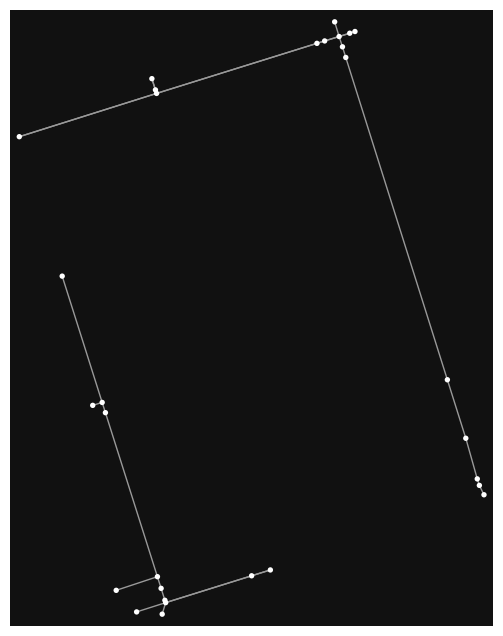

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [16]:
G = ox.graph_from_polygon(polygon = osm_polygon, simplify= False, retain_all=True,truncate_by_edge=True, network_type = 'drive')
graph = ox.project_graph(G, to_crs='epsg:26915')
ox.plot_graph(graph)

Now convert each line segment into road mesh using lanes as parameter to set road width

In [17]:
# Create a list to store GeoDataFrames for each road segment
gdf_roads_list = []
# Set the fixed Z coordinate for the buffer polygons
Z0 = .25  # You can adjust this value based on the desired elevation of the roads
# Create a list to store the meshes
mesh_list = []
mesh_collection = pv.PolyData()
# Iterate over each edge in the graph
for u, v, key, data in graph.edges(keys=True, data=True):
    # Check if the edge has geometry, otherwise create geometries from the nodes
    if 'geometry' not in data:
        data['geometry'] = calculate_edge_geometry(u, v, data)

    # Get the lanes attribute for the edge
    lanes = data.get('lanes', 1)  # Default to 1 lane if lanes attribute is not available

    if not isinstance(lanes, list):
        lanes = [lanes]
        
    # Convert lane values to numeric (integers or floats) using the helper function
    num_lanes = [convert_lane_to_numeric(lane) for lane in lanes]

    # Filter out None values (representing non-numeric lanes) and calculate the road width
    num_lanes = [lane for lane in num_lanes if lane is not None]
    if not num_lanes:
        continue
    road_width = num_lanes[0] * 3.5
    # Buffer the LineString with the road width and add Z coordinate
    line_buffer = data['geometry'].buffer(road_width)
    # Convert the buffer polygon to a PyVista mesh
    exterior_coords = line_buffer.exterior.coords
    z_coordinates = np.full(len(line_buffer.exterior.coords), Z0)
    oriented_coords = list(exterior_coords)
    # Ensure counterclockwise orientation
    if line_buffer.exterior.is_ccw:
        oriented_coords.reverse()
    points = [(coord[0]-center_x, coord[1]-center_y) for coord in oriented_coords]
    # bounding polygon
    boundary_points_polydata = points_2d_to_poly(points, z_coordinates[0])
    mesh = boundary_points_polydata.delaunay_2d()
    # Add the mesh to the list
    mesh_collection = mesh_collection + mesh
    mesh_list.append(mesh)

output_file = f"simple_scene/{LOCATION_DIR}/mesh/road_mesh_combined.ply"
pv.save_meshio(output_file, mesh_collection)

xml_scene_root = globals().get('scene_xml', None)
if xml_scene_root is None and isinstance(globals().get('scene', None), ET.Element):
    xml_scene_root = scene
if xml_scene_root is None:
    existing_xml = Path(f"simple_scene/{LOCATION_DIR}/simple_OSM_scene.xml")
    if existing_xml.exists():
        xml_scene_root = ET.parse(existing_xml).getroot()
        scene_xml = xml_scene_root
        print(f"⚠ scene_xml missing in memory: loaded existing XML from {existing_xml}")
if xml_scene_root is None:
    raise RuntimeError("XML scene root not found. Run cell 6 first or ensure simple_OSM_scene.xml exists.")

# Remove pre-existing roads shape to avoid duplicate IDs when re-running this cell
for old_shape in list(xml_scene_root.findall("./shape[@id='mesh-roads_combined']")):
    xml_scene_root.remove(old_shape)

material_type = "mat-itu_concrete"
# Add shape elements for PLY files in the folder
sionna_shape = ET.SubElement(xml_scene_root, "shape", type="ply", id="mesh-roads_combined")
ET.SubElement(sionna_shape, "string", name="filename", value=f"simple_scene/{LOCATION_DIR}/mesh/road_mesh_combined.ply")
bsdf_ref = ET.SubElement(sionna_shape, "ref", id=material_type, name="bsdf")
ET.SubElement(sionna_shape, "boolean", name="face_normals", value="true")

Warning: PLY doesn't support 64-bit integers. Casting down to 32-bit.

<Element 'boolean' at 0x7b89b687a390>

##### Finally Save the scene file

In [18]:
# Create and write the XML file
xml_scene_root = globals().get('scene_xml', None)
if xml_scene_root is None and isinstance(globals().get('scene', None), ET.Element):
    xml_scene_root = scene
if xml_scene_root is None:
    existing_xml = Path(f"simple_scene/{LOCATION_DIR}/simple_OSM_scene.xml")
    if existing_xml.exists():
        xml_scene_root = ET.parse(existing_xml).getroot()
        scene_xml = xml_scene_root
        print(f"⚠ scene_xml missing in memory: loaded existing XML from {existing_xml}")
if xml_scene_root is None:
    raise RuntimeError("XML scene root not found. Run cell 6 first or ensure simple_OSM_scene.xml exists.")

tree = ET.ElementTree(xml_scene_root)
xml_string = ET.tostring(xml_scene_root, encoding="utf-8")
xml_pretty = minidom.parseString(xml_string).toprettyxml(indent="    ")  # Adjust the indent as needed

with open(f"simple_scene/{LOCATION_DIR}/simple_OSM_scene.xml", "w", encoding="utf-8") as xml_file:
    xml_file.write(xml_pretty)

#### next part is done to simply the scene

In [35]:
from sionna.rt import load_scene
import os

#simple_xml = "/home/pguidetti/sionna/thesis/LTE-italy-SionnaExportTool/simple_scene/HERALD_SQUARE_NYC_5854709.236518181_11307554.105375713/simple_OSM_scene.xml"
simple_xml = "/home/pguidetti/sionna/thesis/LTE-italy-SionnaExportTool/simple_scene/polimi citta studi_5855189.411765975_11307622.744736737/simple_OSM_scene.xml"

if os.path.exists(simple_xml):
    print(f"Caricamento scena...")
    scene = load_scene(simple_xml, merge_shapes=True)
    
    print(f"Oggetti caricati: {len(scene.objects)}")
    for name, obj in scene.objects.items():
        print(f"  - {name}: {obj.radio_material.name}")
        
    # Prova a visualizzare
    scene.preview()
else:
    print(f"File non trovato: {simple_xml}")

Caricamento scena...
2026-04-20 20:34:03 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).
Oggetti caricati: 3
  - roads_combined: itu_concrete
  - no-name-4: itu_marble
  - ground: itu_wet_ground


### Load LTE DB and visualize BTS in selected area
This block reproduces the GUI filtering logic directly in the notebook: load `.ntm`, keep BTS inside the selected polygon, and plot them over the area boundary.

In [36]:
from pathlib import Path
import pandas as pd
from shapely.geometry import Polygon, Point

def cluster_colocated_bts(df):
    if df.empty:
        return df.copy()

    rows = []
    grouped = df.groupby(['Lat', 'Lon'], dropna=False, sort=False)
    for (_, _), group in grouped:
        first = group.iloc[0].copy()
        cluster_size = int(len(group))
        first['cluster_size'] = cluster_size
        first['cluster_cids'] = ','.join(group['CID'].astype(str).tolist())
        if cluster_size > 1:
            tech_values = sorted({str(v) for v in group['Tech'].dropna().astype(str)})
            first['Tech'] = tech_values[0] if len(tech_values) == 1 else f"MIXED({len(tech_values)})"
            first['Desc'] = f"Cluster of {cluster_size} BTS at same coordinates"
        rows.append(first)

    return pd.DataFrame(rows).reset_index(drop=True)

# Use centralized config values when available
if 'NTM_DB_FILENAME' not in globals():
    NTM_DB_FILENAME = "tim_20250716_lteitaly.ntm"
if 'CLUSTER_COLOCATED_BTS' not in globals():
    CLUSTER_COLOCATED_BTS = False

candidate_db_paths = [
    Path.cwd() / NTM_DB_FILENAME,
    Path.cwd().parent / NTM_DB_FILENAME,
]
db_path = next((p for p in candidate_db_paths if p.exists()), None)

if db_path is None:
    raise FileNotFoundError(
        f"Database .ntm not found. Put {NTM_DB_FILENAME} in LTE-italy-SionnaExportTool/ or old/."
    )

df_ntm = pd.read_csv(
    db_path,
    sep=';',
    header=None,
    names=['Tech', 'MCC', 'MNC', 'CID', 'v1', 'eNB', 'v2', 'Lat', 'Lon', 'Desc', 'v3'],
    on_bad_lines='skip'
 )

# Prefer osm_polygon if already computed (WGS84 lon/lat).
if 'osm_polygon' in globals() and osm_polygon is not None:
    selection_polygon_lonlat = osm_polygon
elif 'dc' in globals() and getattr(dc, 'last_draw', None):
    selection_polygon_lonlat = Polygon(dc.last_draw['geometry']['coordinates'][0])
else:
    raise RuntimeError("Selection polygon not available. Execute map selection cells first.")

bts_points = [Point(lon, lat) for lat, lon in zip(df_ntm['Lat'], df_ntm['Lon'])]
inside_mask = [selection_polygon_lonlat.contains(p) or selection_polygon_lonlat.touches(p) for p in bts_points]
bts_in_area = df_ntm[inside_mask].copy()

if CLUSTER_COLOCATED_BTS:
    bts_in_area = cluster_colocated_bts(bts_in_area)
    print("Co-located BTS clustering: ENABLED")
else:
    print("Co-located BTS clustering: DISABLED")

print(f"Database loaded: {db_path}")
print(f"BTS in selected area: {len(bts_in_area)}")

preview_cols = ['Tech', 'CID', 'Lat', 'Lon']
if 'cluster_size' in bts_in_area.columns:
    preview_cols = ['Tech', 'CID', 'Lat', 'Lon', 'cluster_size', 'cluster_cids']

bts_in_area[preview_cols].head(15)

Co-located BTS clustering: DISABLED
Database loaded: /home/pguidetti/sionna/thesis/LTE-italy-SionnaExportTool/tim_20250716_lteitaly.ntm
BTS in selected area: 2


,Tech,CID,Lat,Lon
135762,4G,102,45.479469,9.228879
135765,4G,105,45.480390,9.226642


### Interactive OSM preview (area + BTS overlay)
This map previews the selected area polygon and BTS positions directly on OSM tiles, before JSON export, with the same clustering behavior controlled by CLUSTER_COLOCATED_BTS.

In [37]:
import ipyleaflet
import ipywidgets as widgets
from ipyleaflet import Map, Polygon as LeafletPolygon, CircleMarker, LayersControl

if 'selection_polygon_lonlat' not in globals():
    raise RuntimeError("selection_polygon_lonlat not available. Run the selection and BTS filtering cell first.")
if 'bts_in_area' not in globals():
    raise RuntimeError("bts_in_area not available. Run the BTS filtering cell first.")

center_lat = float(selection_polygon_lonlat.centroid.y)
center_lon = float(selection_polygon_lonlat.centroid.x)

m_preview = Map(
    center=(center_lat, center_lon),
    zoom=16,
    scroll_wheel_zoom=True,
    basemap=ipyleaflet.basemaps.OpenStreetMap.Mapnik,
 )

# Polygon overlay (lat, lon)
poly_latlon = [(float(lat), float(lon)) for lon, lat in selection_polygon_lonlat.exterior.coords]
poly_layer = LeafletPolygon(
    locations=[poly_latlon],
    color="red",
    fill_color="red",
    fill_opacity=0.08,
    weight=2,
    name="Selected area",
)
m_preview.add(poly_layer)

if bts_in_area.empty:
    print("No BTS found in selected area.")
else:
    for _, row in bts_in_area.iterrows():
        lat = float(row['Lat'])
        lon = float(row['Lon'])
        cluster_size = int(row.get('cluster_size', 1)) if 'cluster_size' in bts_in_area.columns else 1
        cid = str(row.get('CID', 'N/A'))
        tech = str(row.get('Tech', 'N/A'))

        if cluster_size > 1:
            popup_html = f"{tech} | cluster_size={cluster_size}<br>CIDs: {row.get('cluster_cids', '')}"
            radius = 7
            color = "orange"
        else:
            popup_html = f"{tech} | CID={cid}"
            radius = 5
            color = "blue"

        marker = CircleMarker(
            location=(lat, lon),
            radius=radius,
            color=color,
            fill_color=color,
            fill_opacity=0.85,
            stroke=True,
            weight=1,
            name="BTS",
        )
        marker.popup = widgets.HTML(value=popup_html)
        m_preview.add(marker)

m_preview.add(LayersControl(position="topright"))
m_preview

Map(center=[45.48019299996403, 9.228269636052648], controls=(ZoomControl(options=['position', 'zoom_in_text', …

In [38]:
import json
import math

if 'NOTEBOOK_PROJECT_NAME' not in globals():
    NOTEBOOK_PROJECT_NAME = "Sionna_Project_1"
if 'EXPORT_PROJECT_JSON' not in globals():
    EXPORT_PROJECT_JSON = True
if 'EXPORT_JSON_FILENAME' not in globals():
    EXPORT_JSON_FILENAME = f"{NOTEBOOK_PROJECT_NAME}.json"

def get_utm_epsg(lon):
    zone = int(math.floor((lon + 180) / 6) + 1)
    return f"EPSG:{32600 + zone}"

def to_json_scalar(value):
    if pd.isna(value):
        return None
    if isinstance(value, np.generic):
        return value.item()
    return value

if 'selection_polygon_lonlat' not in globals():
    raise RuntimeError("selection_polygon_lonlat not available. Run the BTS area selection cell first.")

min_lon, min_lat, max_lon, max_lat = selection_polygon_lonlat.bounds
center_lon = selection_polygon_lonlat.centroid.x
center_lat = selection_polygon_lonlat.centroid.y
utm_epsg = get_utm_epsg(center_lon)

transmitters = []
if 'bts_in_area' in globals() and not bts_in_area.empty:
    for _, row in bts_in_area.iterrows():
        tx = {col: to_json_scalar(row[col]) for col in bts_in_area.columns}
        transmitters.append(tx)

project_json = {
    "project_name": NOTEBOOK_PROJECT_NAME,
    "utm_epsg": utm_epsg,
    "area": {
        "min_lat": min_lat,
        "max_lat": max_lat,
        "min_lon": min_lon,
        "max_lon": max_lon,
        "polygon": [{"lat": lat, "lon": lon} for lon, lat in selection_polygon_lonlat.exterior.coords],
    },
    "center": {"lat": center_lat, "lon": center_lon},
    "transmitters": transmitters,
}

print("JSON preview (same content style as gui.py export):")
print(json.dumps(project_json, indent=2, ensure_ascii=False))

export_path = Path("simple_scene") / LOCATION_DIR / EXPORT_JSON_FILENAME
if EXPORT_PROJECT_JSON:
    export_path.parent.mkdir(parents=True, exist_ok=True)
    with open(export_path, "w", encoding="utf-8") as f:
        json.dump(project_json, f, indent=4, ensure_ascii=False)
    print(f"\nJSON exported to: {export_path.resolve()}")
else:
    print("\nEXPORT_PROJECT_JSON=False -> preview only, file not written.")

JSON preview (same content style as gui.py export):
{
  "project_name": "citta studi",
  "utm_epsg": "EPSG:32632",
  "area": {
    "min_lat": 45.479315,
    "max_lat": 45.481053,
    "min_lon": 9.22649,
    "max_lon": 9.230031,
    "polygon": [
      {
        "lat": 45.47936,
        "lon": 9.226544
      },
      {
        "lat": 45.481053,
        "lon": 9.22649
      },
      {
        "lat": 45.48103,
        "lon": 9.230031
      },
      {
        "lat": 45.479315,
        "lon": 9.229998
      },
      {
        "lat": 45.47936,
        "lon": 9.226544
      }
    ]
  },
  "center": {
    "lat": 45.48019299996403,
    "lon": 9.228269636052648
  },
  "transmitters": [
    {
      "Tech": "4G",
      "MCC": 222,
      "MNC": 1,
      "CID": 102,
      "v1": 0,
      "eNB": 505158,
      "v2": 0,
      "Lat": 45.479469,
      "Lon": 9.2288787,
      "Desc": "B7 Polimi Nave / Trifoglio",
      "v3": 3175
    },
    {
      "Tech": "4G",
      "MCC": 222,
      "MNC": 1,
      "CID"

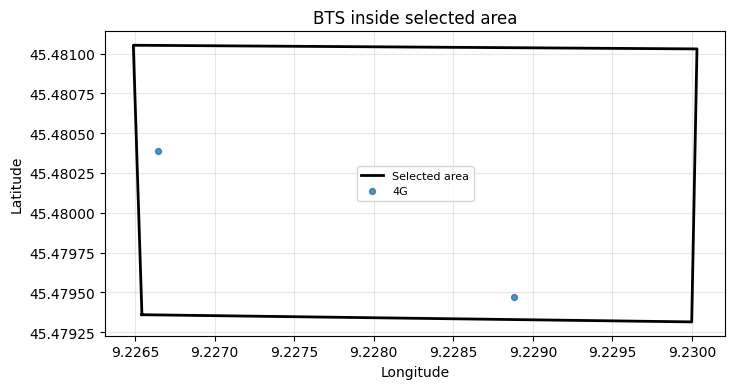

In [39]:
import matplotlib.pyplot as plt

if bts_in_area.empty:
    print("No BTS found in the selected polygon.")
else:
    fig, ax = plt.subplots(figsize=(8, 8))

    # Plot selection boundary
    bx, by = selection_polygon_lonlat.exterior.xy
    ax.plot(bx, by, color='black', linewidth=2, label='Selected area')

    # Plot BTS grouped by technology
    for tech, group in bts_in_area.groupby('Tech'):
        ax.scatter(group['Lon'], group['Lat'], s=18, alpha=0.8, label=str(tech))

    ax.set_title('BTS inside selected area')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_aspect('equal', adjustable='box')
    ax.grid(alpha=0.3)
    ax.legend(loc='best', fontsize=8)
    plt.show()

### Import exported scene and run RT on synthetic BS
This section loads the latest exported scene geometry/metadata, then creates random synthetic BS for a controlled ray-tracing test (independent from selected BTS).

✓ Detected Project: polimi citta studi_5855189.411765975_11307622.744736737
✓ XML Scene: simple_OSM_scene.xml
✓ JSON Loaded: citta studi.json
✓ Detected EPSG: EPSG:32632
⚠ Normalized 20 mesh path(s) from exported XML.
2026-04-20 20:34:07 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).
Added synthetic BS_SYN_1 at [9.6, -63.2, 32.9] m
Added synthetic BS_SYN_2 at [-9.6, -27.8, 34.6] m
Added synthetic BS_SYN_3 at [6.9, -98.4, 21.9] m
Added synthetic BS_SYN_4 at [-54.3, 17.5, 33.9] m
✓ Scene loaded with 4 synthetic BS for RT demo.


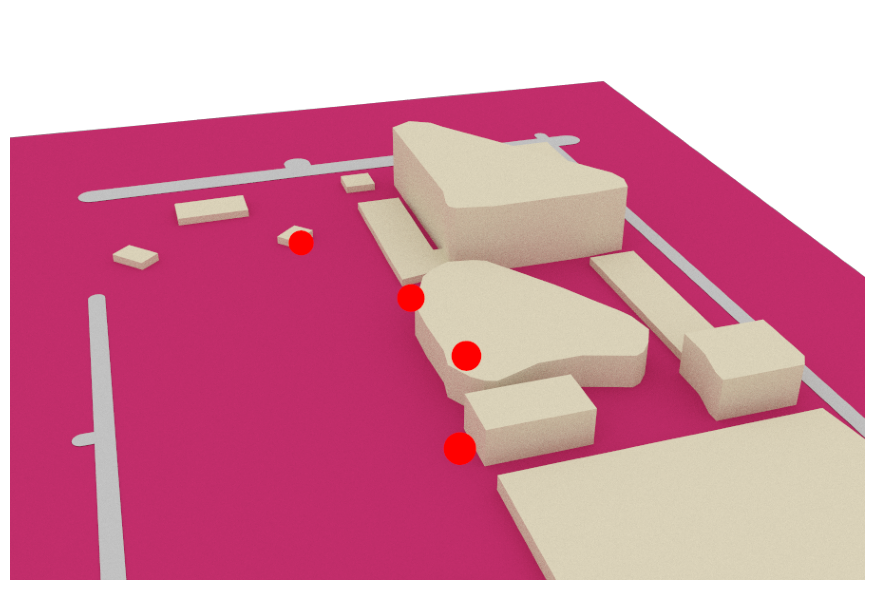

In [40]:
import json
from pathlib import Path
import os
import tempfile
import numpy as np
from pyproj import Transformer
import xml.etree.ElementTree as ET
from sionna.rt import load_scene, Transmitter, Receiver, PlanarArray, PathSolver, Camera

# Use centralized config values, fallback to safe defaults
if 'NOTEBOOK_PROJECT_NAME' not in globals():
    NOTEBOOK_PROJECT_NAME = "Sionna_Project_1"
if 'no_preview_rt' not in globals():
    no_preview_rt = True
if 'RT_USE_SYNTHETIC_BS' not in globals():
    RT_USE_SYNTHETIC_BS = True
if 'RT_SYNTH_BS_COUNT' not in globals():
    RT_SYNTH_BS_COUNT = 4
if 'RT_SYNTH_BS_RADIUS_M' not in globals():
    RT_SYNTH_BS_RADIUS_M = 120.0
if 'RT_SYNTH_BS_MIN_H_M' not in globals():
    RT_SYNTH_BS_MIN_H_M = 20.0
if 'RT_SYNTH_BS_MAX_H_M' not in globals():
    RT_SYNTH_BS_MAX_H_M = 35.0
if 'RT_RANDOM_SEED' not in globals():
    RT_RANDOM_SEED = 42

BASE_DIR = Path.cwd()
SIMPLE_SCENE_DIR = BASE_DIR / "simple_scene"
if not SIMPLE_SCENE_DIR.exists():
    raise FileNotFoundError("'simple_scene' folder not found. Export a project first.")

project_folders = [d for d in SIMPLE_SCENE_DIR.iterdir() if d.is_dir()]
if not project_folders:
    raise FileNotFoundError("No projects found in 'simple_scene'.")

LATEST_PROJECT_DIR = max(project_folders, key=os.path.getmtime)
XML_SCENE = LATEST_PROJECT_DIR / "simple_OSM_scene.xml"
JSON_FILES = list(LATEST_PROJECT_DIR.glob("*.json"))

if not XML_SCENE.exists():
    raise FileNotFoundError(f"Could not find XML scene in {LATEST_PROJECT_DIR}")

project = {
    "utm_epsg": "EPSG:32633",
    "center": {"lat": 0.0, "lon": 0.0},
    "transmitters": []
}
has_project_json = False

JSON_FILE = JSON_FILES[0] if JSON_FILES else None
if JSON_FILE is None:
    legacy_json = BASE_DIR / f"{NOTEBOOK_PROJECT_NAME}.json"
    if legacy_json.exists():
        JSON_FILE = legacy_json

if JSON_FILE is not None:
    try:
        with open(JSON_FILE, "r", encoding="utf-8") as f:
            project = json.load(f)
        has_project_json = True
    except Exception as json_error:
        print(f"⚠ JSON found but not readable ({json_error}). Continuing with defaults.")

print(f"✓ Detected Project: {LATEST_PROJECT_DIR.name}")
print(f"✓ XML Scene: {XML_SCENE.name}")
if has_project_json:
    print(f"✓ JSON Loaded: {Path(JSON_FILE).name}")
else:
    print("⚠ No JSON found. Continuing with defaults.")
print(f"✓ Detected EPSG: {project.get('utm_epsg', 'EPSG:32633')}")

target_epsg = project.get('utm_epsg', 'EPSG:32633')
wgs84 = 'EPSG:4326'
transformer = Transformer.from_crs(wgs84, target_epsg, always_xy=True)
center_gps = project.get('center', {'lat': 0.0, 'lon': 0.0})
center_m = transformer.transform(center_gps['lon'], center_gps['lat'])

def gps_to_sionna(lon, lat, height=30.0):
    pos_m = transformer.transform(lon, lat)
    return [float(pos_m[0] - center_m[0]), float(pos_m[1] - center_m[1]), float(height)]

# Normalize mesh filenames in XML if they are stored with duplicated project prefixes
xml_tree = ET.parse(XML_SCENE)
xml_root = xml_tree.getroot()
missing_meshes = []
updated_paths = 0

for shape_node in xml_root.findall(".//shape[@type='ply']"):
    filename_node = shape_node.find("string[@name='filename']")
    if filename_node is None:
        continue
    mesh_rel_path = filename_node.attrib.get('value', '')

    candidate_1 = (XML_SCENE.parent / mesh_rel_path).resolve()
    candidate_2 = (BASE_DIR / mesh_rel_path).resolve()

    if candidate_1.exists():
        continue
    if candidate_2.exists():
        fixed_rel = os.path.relpath(candidate_2, XML_SCENE.parent)
        filename_node.set('value', fixed_rel)
        updated_paths += 1
        continue

    prefix = f"simple_scene/{LATEST_PROJECT_DIR.name}/"
    if mesh_rel_path.startswith(prefix):
        stripped = mesh_rel_path[len(prefix):]
        candidate_3 = (XML_SCENE.parent / stripped).resolve()
        if candidate_3.exists():
            filename_node.set('value', stripped)
            updated_paths += 1
            continue

    missing_meshes.append(mesh_rel_path)

if missing_meshes:
    raise FileNotFoundError(
        "Missing mesh files referenced by XML after path normalization:\n" + "\n".join(missing_meshes[:10])
    )

if updated_paths > 0:
    print(f"⚠ Normalized {updated_paths} mesh path(s) from exported XML.")

tmp_xml_file = tempfile.NamedTemporaryFile(
    dir=str(XML_SCENE.parent), suffix='.xml', delete=False
 )
tmp_xml_path = Path(tmp_xml_file.name)
tmp_xml_file.close()
xml_tree.write(tmp_xml_path, encoding='utf-8', xml_declaration=True)

scene_rt = load_scene(str(tmp_xml_path.resolve()))
for tx_name in list(scene_rt.transmitters.keys()):
    scene_rt.remove(tx_name)

# Synthetic BS generation for RT demo (does not use selected/exported BTS positions)
if RT_USE_SYNTHETIC_BS:
    rng = np.random.default_rng(RT_RANDOM_SEED)
    for i in range(RT_SYNTH_BS_COUNT):
        angle = float(rng.uniform(0.0, 2.0 * np.pi))
        radius = float(rng.uniform(20.0, RT_SYNTH_BS_RADIUS_M))
        h = float(rng.uniform(RT_SYNTH_BS_MIN_H_M, RT_SYNTH_BS_MAX_H_M))
        x = float(radius * np.cos(angle))
        y = float(radius * np.sin(angle))
        tx = Transmitter(name=f"BS_SYN_{i+1}", position=[x, y, float(h)], display_radius=5.0)
        scene_rt.add(tx)
        print(f"Added synthetic {tx.name} at [{x:.1f}, {y:.1f}, {h:.1f}] m")
else:
    print("RT_USE_SYNTHETIC_BS=False, no synthetic BS added in this cell.")

scene_rt.tx_array = PlanarArray(num_rows=1, num_cols=1, pattern='dipole', polarization='V')
scene_rt.rx_array = PlanarArray(num_rows=1, num_cols=1, pattern='dipole', polarization='V')
print(f"✓ Scene loaded with {len(scene_rt.transmitters)} synthetic BS for RT demo.")

if no_preview_rt:
    cam = Camera(position=[0, -350, 220], look_at=[0, 0, 20])
    scene_rt.render(camera=cam, resolution=[900, 600], num_samples=128)
else:
    scene_rt.preview()

✓ Added receiver 'UE_center' at [0, 0, 1.5] m
✓ Ray tracing completed. Total active paths (max per link): 8


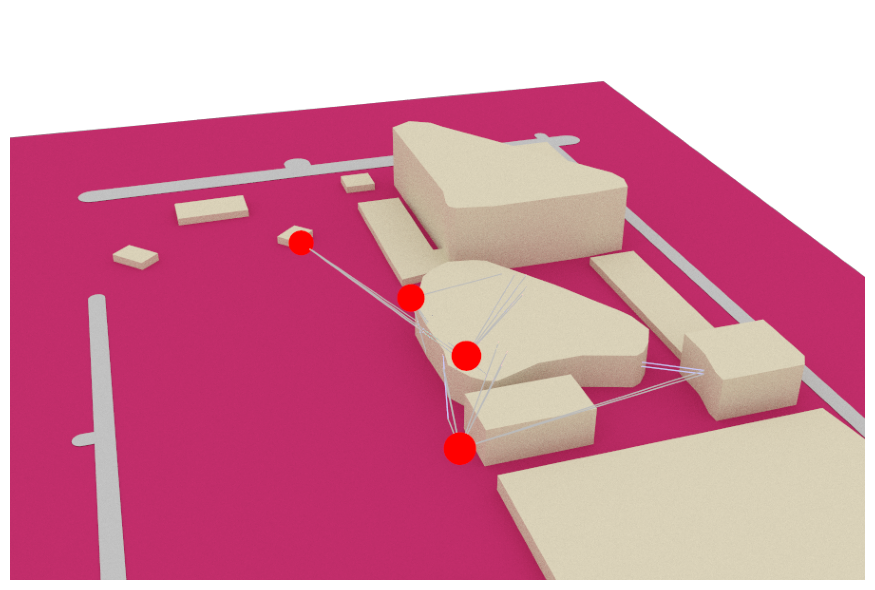

In [41]:
if 'scene_rt' not in globals() or scene_rt is None:
    raise RuntimeError("scene_rt not loaded. Run the previous import cell first.")

if len(scene_rt.transmitters) == 0:
    raise RuntimeError("No transmitters in scene_rt. Enable RT_USE_SYNTHETIC_BS or add transmitters before tracing.")

ue_name = 'UE_center'
if ue_name in scene_rt.receivers:
    scene_rt.remove(ue_name)
ue = Receiver(name=ue_name, position=[0.0, 0.0, 1.5], display_radius=5.0)
scene_rt.add(ue)

for tx_obj in scene_rt.transmitters.values():
    tx_obj.look_at(ue)

solver = PathSolver()
paths_rt = solver(
    scene=scene_rt,
    max_depth=3,
    los=True,
    specular_reflection=True,
    diffuse_reflection=False,
    refraction=True,
    synthetic_array=True,
    seed=RT_RANDOM_SEED if 'RT_RANDOM_SEED' in globals() else 42,
 )

_, tau = paths_rt.cir(normalize_delays=True, out_type='numpy')
valid_entries = np.isfinite(tau) & (tau >= 0)
num_paths = int(np.max(np.sum(valid_entries, axis=-1)))
print(f"✓ Added receiver '{ue_name}' at [0, 0, 1.5] m")
print(f"✓ Ray tracing completed. Total active paths (max per link): {num_paths}")

if no_preview_rt:
    cam_rt = Camera(position=[0, -350, 220], look_at=[0, 0, 20])
    scene_rt.render(camera=cam_rt, paths=paths_rt, resolution=[900, 600], num_samples=128)
else:
    scene_rt.preview(paths=paths_rt, clip_at=250)

In [43]:
scene_rt.preview(paths=paths_rt, clip_at=250)